Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load continuous wrist flexion data from Delsys Mini sensor

In [12]:
df = pd.read_csv("mini_isometric_male.csv", header=0)
df.columns = ["ch_1_time", "ch_1_voltage"]
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna()

C:\Users\xvanq\AppData\Local\Temp\ipykernel_12204\3766864873.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mini_isometric_male.csv", header=0)


Define function to compute MDF over time for multiple EMG channels

In [13]:
# Inputs: Array of time (s) values, array of voltage (mV) values, window size (s), step size (s)
# Outputs: Array of time values (s), array of MDF values (Hz)

def compute_mdf(channel_time, channel_voltage, window_time, step_time):

    # Define axes
    time = channel_time.to_numpy()
    voltage = channel_voltage.to_numpy()

    # Subtract mean to remove DC offset (spike at 0 Hz)
    voltage = voltage - np.mean(voltage)

    # Sampling information
    dt = np.mean(np.diff(time))             # Interval in seconds (mean time between samples)
    Fs = 1 / dt                             # Frequency in Hz
    N = len(voltage)                        # Number of samples
    window_size = int(window_time * Fs)     # Number of samples in each window
    step_size = int(step_time * Fs)         # Number of samples to step for each

    window_times = []
    mdf_values = []

    # Loop through windows
    for start in range(0, N - window_size + 1, step_size):
        end = start + window_size
        
        # Time and voltage values for current window
        segment_time = time[start:end]
        segment_voltage = voltage[start:end]

        # FFT
        fft_amplitude = np.fft.fft(segment_voltage)
        fft_freq = np.fft.fftfreq(window_size, d=dt)

        # Keep only positive frequencies
        freqs = fft_freq[fft_freq >= 0]

        # Calculate signal power values
        power = np.abs(fft_amplitude[fft_freq >= 0]) ** 2   # Power is the square of the amplitude
        cumulative_power = np.cumsum(power)                 # Cumulative sum of power
        total_power = np.sum(power)                         # Total power in the signal

        # Calculate MDF as the first value where cumulative power >= 50% of total power
        mdf = freqs[np.where(cumulative_power >= 0.5 * total_power)[0][0]]

        # Use the midpoint of the window as the corresponding time for each MDF value
        window_times.append(segment_time[len(segment_time) // 2])
        mdf_values.append(mdf)

    return np.array(window_times), np.array(mdf_values)


Plot MDF outputs

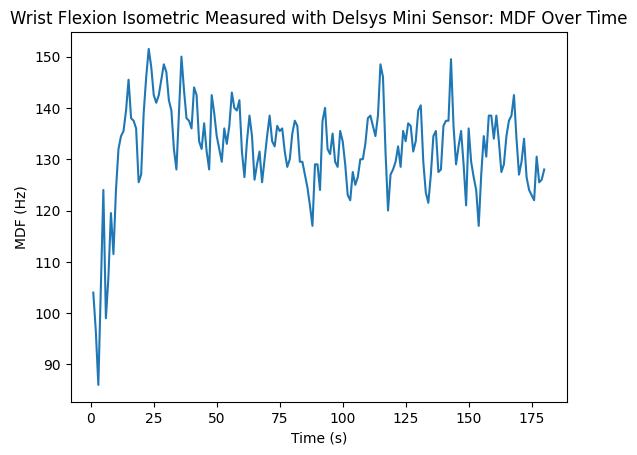

In [14]:
time, mdf = compute_mdf(df["ch_1_time"], df["ch_1_voltage"], window_time=2, step_time=1)

plt.plot(time, mdf)
plt.title("Wrist Flexion Isometric Measured with Delsys Mini Sensor: MDF Over Time")
plt.xlabel("Time (s)")
plt.ylabel("MDF (Hz)")
plt.show()